# **MÓDULO 13**
# Projeto - Fundamentos da Descoberta de Dados

Nesse projeto trabalharemos com a base de dados de produtos de um supermercado do Chile.
A ideia é que vocês apliquem os conceitos estatísticos vistos no último módulo, mais os conceitos de visualizações de dados através de gráficos e finalizem publicando no seu github!

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

Faça a leitura dos dados do arquivo CSV:


Altere o código abaixo de acordo com seu diretório.

In [30]:
df = pd.read_csv("MODULO7_PROJETOFINAL_BASE_SUPERMERCADO.csv", delimiter=',')
df.info()
df.columns
df.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 1107 entries, 0 to 1106
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   title           1107 non-null   str  
 1   Marca           1107 non-null   str  
 2   Preco_Normal    1107 non-null   int64
 3   Preco_Desconto  1107 non-null   int64
 4   Preco_Anterior  1107 non-null   int64
 5   Desconto        1107 non-null   int64
 6   Categoria       1107 non-null   str  
dtypes: int64(4), str(3)
memory usage: 60.7 KB


,title,Marca,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto,Categoria
0,"Pack 12 un, Leche extra proteína 1 L",Loncoleche,19788,0,0,0,lacteos
1,"Pack 12 un, Leche chocolate receta original 1 L",Soprole,18228,0,0,0,lacteos
2,"Pack 12 un, Leche semidescremada chocolate 1 L",Soprole,18228,0,0,0,lacteos
3,"Pack 12 un, Leche semidescremada frutilla 1 L",Soprole,18228,0,0,0,lacteos
4,"Pack 12 un, Leche sin lactosa chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
5,"Pack 12 un, Leche sin lactosa frutilla 1 L",Loncoleche,17988,0,0,0,lacteos
6,"Pack 12 un, Leche saborizada light chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
7,"Pack 12 un, Leche saborizada frutilla 1 L",Colun,17388,0,0,0,lacteos
8,"Pack 12 un, Leche saborizada vainilla 1 L",Colun,17388,0,0,0,lacteos
9,"Pack 12 un, Leche saborizada manjar 1 L",Colun,17388,0,0,0,lacteos


import os
os.listdir()
#Para achar o nome do arquivo, o problema era que o nome já tinha .csv e dps outro .csv ele não reconhecia

In [4]:
df.isnull().sum()

title             0
Marca             0
Preco_Normal      0
Preco_Desconto    0
Preco_Anterior    0
Desconto          0
Categoria         0
dtype: int64

In [31]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

colunas_numericas = ["Preco_Normal","Preco_Desconto","Preco_Anterior"]

df[colunas_numericas] = scaler.fit_transform(df[colunas_numericas])

df.head()

,title,Marca,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto,Categoria
0,"Pack 12 un, Leche extra proteína 1 L",Loncoleche,1.000000,0.0,0.0,0,lacteos
1,"Pack 12 un, Leche chocolate receta original 1 L",Soprole,0.921164,0.0,0.0,0,lacteos
2,"Pack 12 un, Leche semidescremada chocolate 1 L",Soprole,0.921164,0.0,0.0,0,lacteos
3,"Pack 12 un, Leche semidescremada frutilla 1 L",Soprole,0.921164,0.0,0.0,0,lacteos
4,"Pack 12 un, Leche sin lactosa chocolate 1 L",Loncoleche,0.909036,0.0,0.0,0,lacteos


Os campos do nosso dataframe são:

**Title:** Nome do produto.


**Marca:** A marca do produto.


**Preco_Normal:** O preço em que o produto costuma ser vendido quando não há desconto.


**Preco_Desconto:** O preço vendido após o desconto ser aplicado.


**Preco_Anterior:** Preço em que era comercializado o produto antes do desconto aplicado.


**Desconto:** Total de desconto aplicado.






As colunas que aparecem com valores 0 são para os produtos onde não tivemos descontos aplicados.


As categorias estão em espanhol!

# 1 - Traga a média e a mediana dos preços - coluna Preco_Normal - por categoria de produto.
# Identifique as categorias que parecem ter um valor de média abaixo ou acima da mediana.
A única categoria que apresenta média inferior à mediana é comidas-preparadas. A diferença entre esses valores é de aproximadamente 0,0098, o que pode indicar a presença de alguns preços mais baixos influenciando e reduzindo o valor médio dessa categoria. Já nas demais categorias, observa-se o comportamento oposto, em que a média é superior à mediana. Esse padrão sugere a presença de outliers que acabam puxando a média para cima em relação à mediana(como é possível visualizar no gráfico).

In [32]:
#Seu código aqui para a média
media_preco = df.groupby("Categoria")["Preco_Normal"].mean()
media_preco


Categoria
belleza-y-cuidado-personal    0.090133
comidas-preparadas            0.156410
congelados                    0.106531
frutas                        0.087147
instantaneos-y-sopas          0.038685
lacteos                       0.120539
verduras                      0.067884
Name: Preco_Normal, dtype: float64

In [33]:
#Seu código aqui para a mediana
mediana_preco = df.groupby("Categoria")["Preco_Normal"].median()
mediana_preco

Categoria
belleza-y-cuidado-personal    0.079290
comidas-preparadas            0.166262
congelados                    0.076764
frutas                        0.060390
instantaneos-y-sopas          0.022185
lacteos                       0.049980
verduras                      0.059632
Name: Preco_Normal, dtype: float64

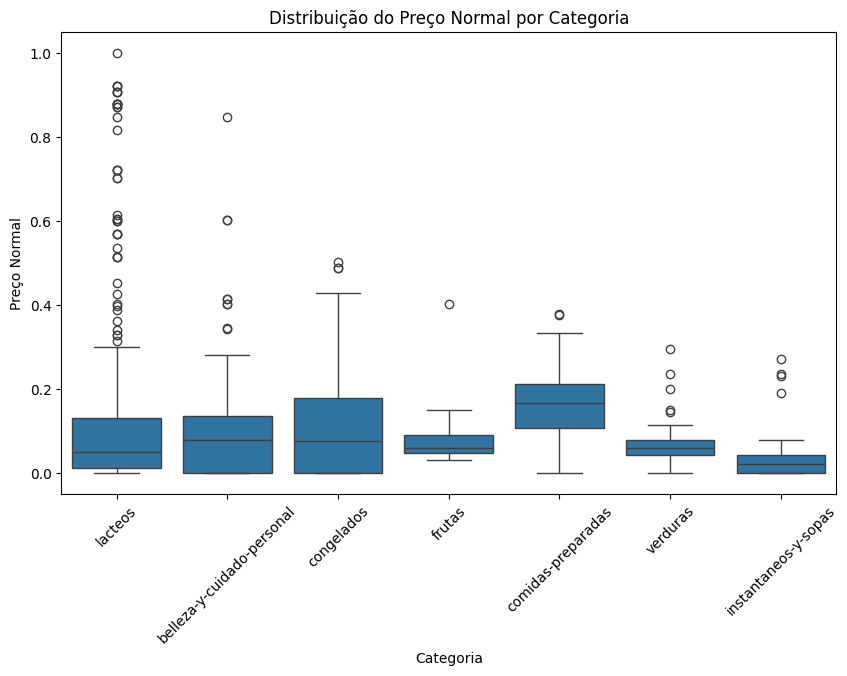

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.boxplot(x="Categoria", y="Preco_Normal", data=df)

plt.title("Distribuição do Preço Normal por Categoria")
plt.xlabel("Categoria")
plt.ylabel("Preço Normal")

plt.xticks(rotation=45)

plt.show()

# 2 - Traga o desvio padrão por categoria de produto.
# Qual o comportamento da média e mediana nas categorias com maior desvio? 



In [35]:
dp_preco = df.groupby("Categoria")["Preco_Normal"].std()

dp_preco


Categoria
belleza-y-cuidado-personal    0.111686
comidas-preparadas            0.102078
congelados                    0.106708
frutas                        0.082836
instantaneos-y-sopas          0.059139
lacteos                       0.198394
verduras                      0.051177
Name: Preco_Normal, dtype: float64

Nas quatro categrias com maior desvio padrão(belleza-y-cuidado-personal,comidas-preparadas,congelados e lacteos) a média é maior que a mediana indicando a presença de valores positivos aumentando o valor médio. Entratento, é importante destacar que para comidas-preparadas a média é ligeiramente menor que a mediana sugerindo que preços mais baixos estão estabilizando a categoria.


# 3 - Plot um boxplot da distribuição do Preco_Normal para a categoria que você identificou que tem o maior desvio padrão. Como é a distribuição desses dados segundo o boxplot? Você identifica muitos outliers?

Dica: Para trazer apenas os dados da categoria que você deseja você pode usar o df.loc[df['Categoria'] == 'CATEGORIA ESCOLHIDA'

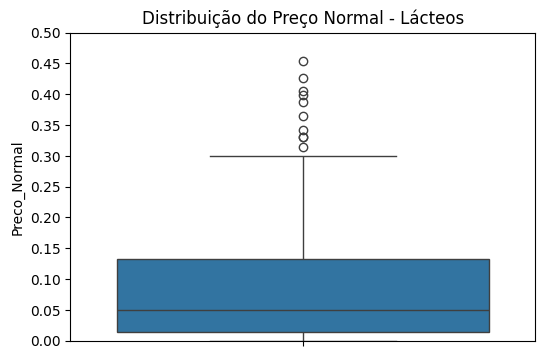

In [36]:
#Seu código aqui
import numpy as np
df_lacteos = df.loc[df['Categoria'] == 'lacteos']
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.boxplot(y=df_lacteos['Preco_Normal'])

plt.title("Distribuição do Preço Normal - Lácteos")
plt.ylim(0,0.5)
plt.yticks(np.arange(0, 0.51, 0.05))

plt.show()

In [ ]:
Os valores de um modo geral estão concentrados nos níveis mais baixos da escala normalizada mostrando que a maioria dos produtos 
tem preços relativamente próximos entre si quando comparados ao intervalo total de dados.A mediana está em torno de 0.05 o que indica que a metade 
dos valores estão abaixo desse ponto e metade acima. Também é possível observar a presença de diversos outliers o que explica um pouco o maior dp
já que esses valores contribuem para aumentar a dispersão dos dados.


# 4 - Plote um gráfico de barras onde temos a média de descontos por categoria.

C:\Users\Regina\AppData\Local\Temp\ipykernel_15304\2069071703.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=media_descontos, x='Categoria', y='Desconto', palette='viridis', width=0.6)


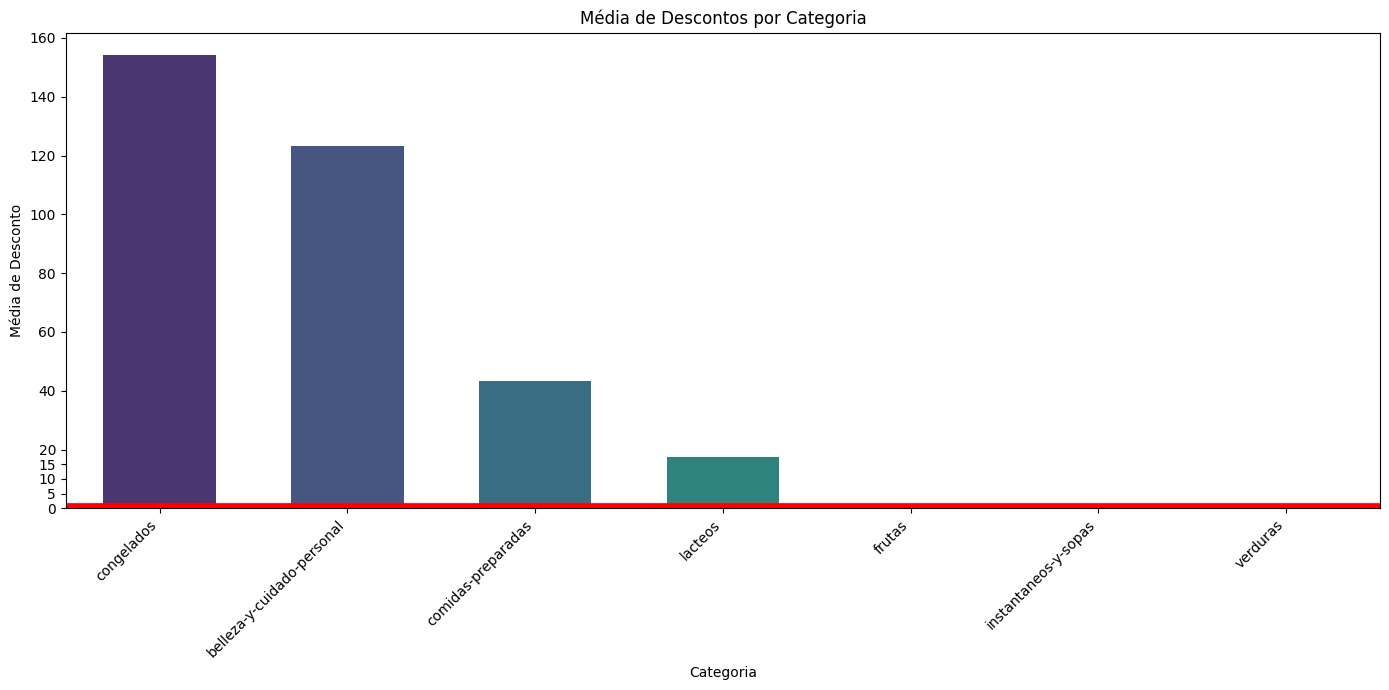

In [57]:
media_descontos = df.groupby('Categoria')['Desconto'].mean().reset_index()
media_descontos = media_descontos.sort_values(by='Desconto', ascending=False)
plt.figure(figsize=(14,7))
sns.barplot(data=media_descontos, x='Categoria', y='Desconto', palette='viridis', width=0.6)
plt.xticks(rotation=45, ha='right')
plt.title('Média de Descontos por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Média de Desconto')
plt.yticks([0,5,10,15,20,40,60,80,100,120,140,160])
plt.axhline(0, color='red', linewidth=7.0)
plt.tight_layout()
plt.show()


#print(df['Desconto'].head())
teste_categoria_zero1 = 'frutas'
media_categoria2 = df[df['Categoria'] == teste_categoria_zero1]['Desconto'].mean()
print(media_categoria2)

In [51]:
#teste_categoria_zero1 = 'instantaneos-y-sopas'
#media_categoria2 = df[df['Categoria'] == teste_categoria_zero1]['Desconto'].mean()
#print(media_categoria2)

#teste_categoria_zero1 = 'verduras'
#media_categoria2 = df[df['Categoria'] == teste_categoria_zero1]['Desconto'].mean()
#print(media_categoria2)

teste_categoria_zero1 = 'lacteos'
media_categoria2 = df[df['Categoria'] == teste_categoria_zero1]['Desconto'].mean()
print(media_categoria2)





17.411633109619686


# 5 - Plote um gráfico de mapa interativo agrupando os dados por categoria, marca e trazendo a média de desconto.

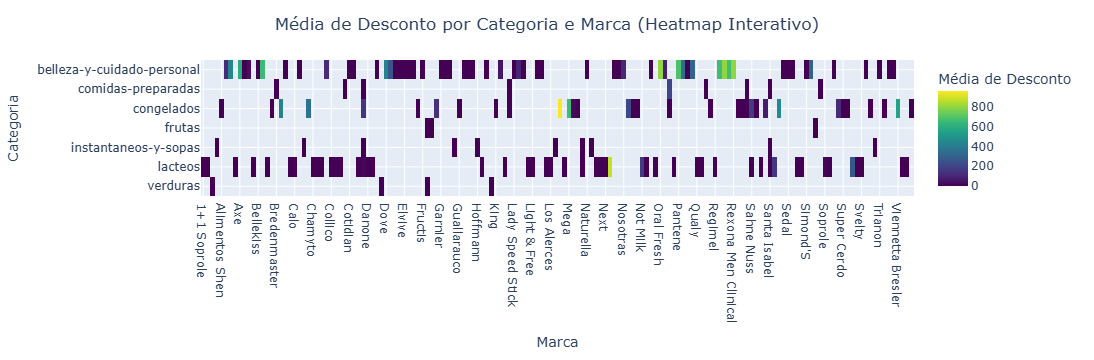

In [63]:

media_descontos2 = df.groupby(['Categoria','Marca'], as_index=False)['Desconto'].mean()
tabela_heatmap = media_descontos2.pivot(index='Categoria', columns='Marca', values='Desconto')
fig = px.imshow(
    tabela_heatmap,
    text_auto=True,                
    color_continuous_scale='Viridis',
    aspect="auto",
    labels=dict(x="Marca", y="Categoria", color="Média de Desconto"),
)

fig.update_layout(title="Média de Desconto por Categoria e Marca")
fig.show()